## Logistic Classification 

1 Setup libraries

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

import joblib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

2 Setup file path

In [3]:
file_path = '../data/data_2/data_labeled.json'

df = pd.read_json(file_path)
df.head()

,Transaction ID,Sender Account ID,Receiver Account ID,Transaction amount,Timestamp,Transaction Detail,Geological,Device Use,Gender,Location,Account balance,Transaction Count,Working Status,Salary (per month),Age,Balance_to_Salary_Ratio,Transaction_to_Balance_Ratio,Hour,DayOfWeek,is_fraud,anomaly_score
0,TXN_300001,ACC_06255,REC_3912,0.436816,2025-11-17 07:34:00,3,1,4,2,1,0.252505,10,2,0.177778,0.414634,0.097504,0.003572,7,0,0,-0.539102
1,TXN_300002,ACC_04472,REC_7262,0.168972,2025-08-13 07:31:00,1,1,3,1,6,0.088176,3,5,0.355556,0.170732,0.021225,0.003929,7,2,0,-0.517723
2,TXN_300003,ACC_00398,REC_3277,0.309114,2025-01-24 15:14:00,1,1,3,0,0,0.326653,4,5,0.266667,0.463415,0.096282,0.001959,15,4,0,-0.482311
3,TXN_300004,ACC_06061,REC_4510,0.923370,2025-08-16 20:45:00,6,2,2,2,6,0.462926,2,2,0.933333,0.926829,0.049164,0.004124,20,5,0,-0.514468
4,TXN_300005,ACC_09143,REC_4206,0.368501,2025-05-06 21:27:00,0,2,2,0,5,0.749499,2,3,0.377778,0.048780,0.170282,0.001018,21,1,0,-0.502332


3 Feature Selection and Preparation

Here we define which columns we are using and split the data into features ($X$) and the target variable ($y$).

In [4]:
feature_columns = [
    'Transaction amount', 'Account balance', 'Salary (per month)',
    'Hour', 'DayOfWeek', 'Age', 'Is_Weekend', 'Is_Night',
    'Balance_to_Salary_Ratio', 'Transaction_to_Balance_Ratio',
    'Transaction Detail', 'Geological', 'Device Use',
    'Location', 'Working Status', 'Gender', 'Transaction Count'
]

# Ensure we only use columns that actually exist in the dataframe
available_cols = [col for col in feature_columns if col in df.columns]
X = df[available_cols].copy()
y = df['is_fraud']

print(f"Features being used: {available_cols}")

Features being used: ['Transaction amount', 'Account balance', 'Salary (per month)', 'Hour', 'DayOfWeek', 'Age', 'Balance_to_Salary_Ratio', 'Transaction_to_Balance_Ratio', 'Transaction Detail', 'Geological', 'Device Use', 'Location', 'Working Status', 'Gender', 'Transaction Count']


4 Model Training

In [5]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


5 Evaluation

In [6]:
predictions = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}\n")
print(classification_report(y_test, predictions, target_names=['Normal', 'Fraud']))

Accuracy: 87.50%

              precision    recall  f1-score   support

      Normal       0.88      0.99      0.93      4240
       Fraud       0.78      0.24      0.37       760

    accuracy                           0.88      5000
   macro avg       0.83      0.62      0.65      5000
weighted avg       0.87      0.88      0.85      5000



6 Feature Importance (Coefficients)

In Logistic Regression, the coefficients tell us the influence of each feature on the probability of fraud.

In [9]:
coef_df = pd.DataFrame({
    'Features': available_cols,
    'Coefficients': model.coef_[0]
}).sort_values('Coefficients', ascending=False, key=abs)
print(coef_df.head(5).to_string(index=False))

                    Features  Coefficients
Transaction_to_Balance_Ratio     17.547587
     Balance_to_Salary_Ratio      9.193456
             Account balance     -3.292549
          Salary (per month)      0.959017
          Transaction amount      0.760886


6 Visualizations

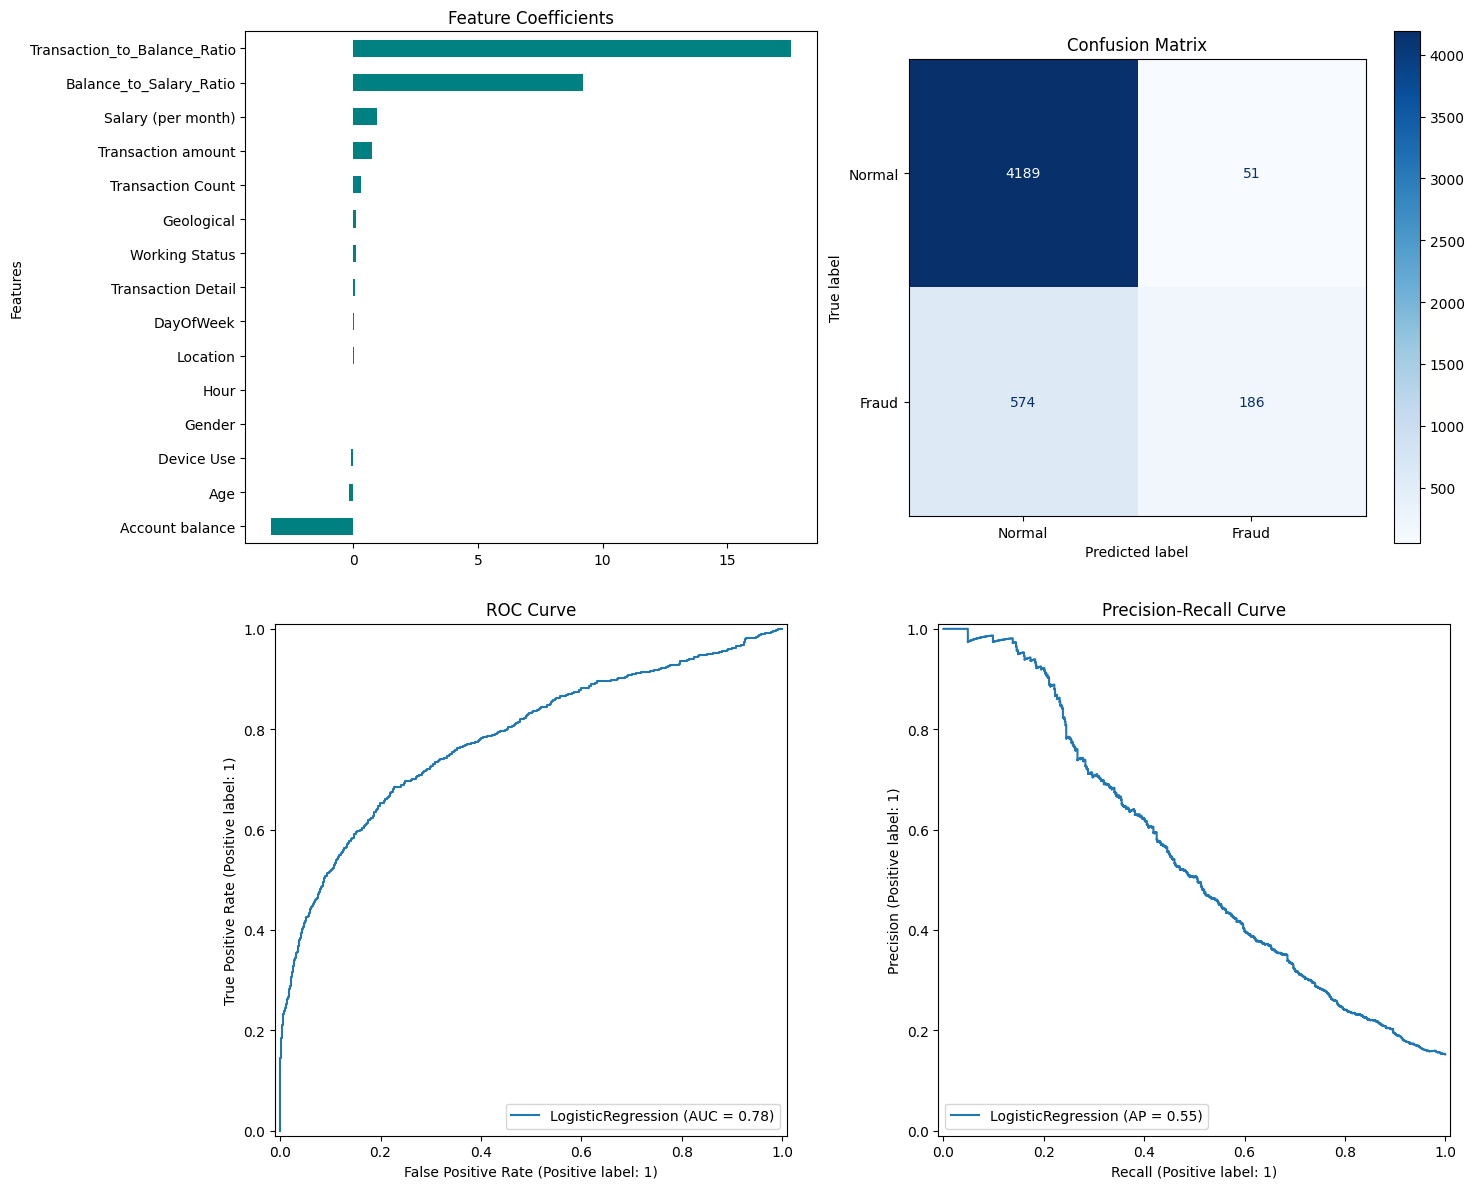

In [10]:
# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Feature Coefficients
coef_df.sort_values('Coefficients').plot(
    kind='barh', x='Features', y='Coefficients', 
    legend=False, color='teal', ax=axes[0, 0]
)
axes[0, 0].set_title('Feature Coefficients')

# 2. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, predictions, 
    display_labels=['Normal', 'Fraud'], 
    cmap='Blues', ax=axes[0, 1]
)
axes[0, 1].set_title('Confusion Matrix')

# 3. ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1, 0])
axes[1, 0].set_title('ROC Curve')

# 4. Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[1, 1])
axes[1, 1].set_title('Precision-Recall Curve')

plt.tight_layout()

plt.show()